## Step 2: Feature Encoding & Modeling
Tahap ini adalah tempat kamu melatih "otak" AI untuk belajar pola dari data yang sudah bersih.

## 1. Label Encoding (Categorical to Numerical)

In [9]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Data Cleaning Source
df = pd.read_csv(r'D:\finish\New folder\Kuliah\Semester 6\Yapay Zeka\yapayzeka\Data\Processed\ecommerce_clean.csv')

# Convert String to Int
le = LabelEncoder()
df['category_n'] = le.fit_transform(df['category'])
df['sub_cat_n'] = le.fit_transform(df['sub_category'])
df['region_n'] = le.fit_transform(df['region'])

## 2. Machine Learning Modeling (Decision Tree)

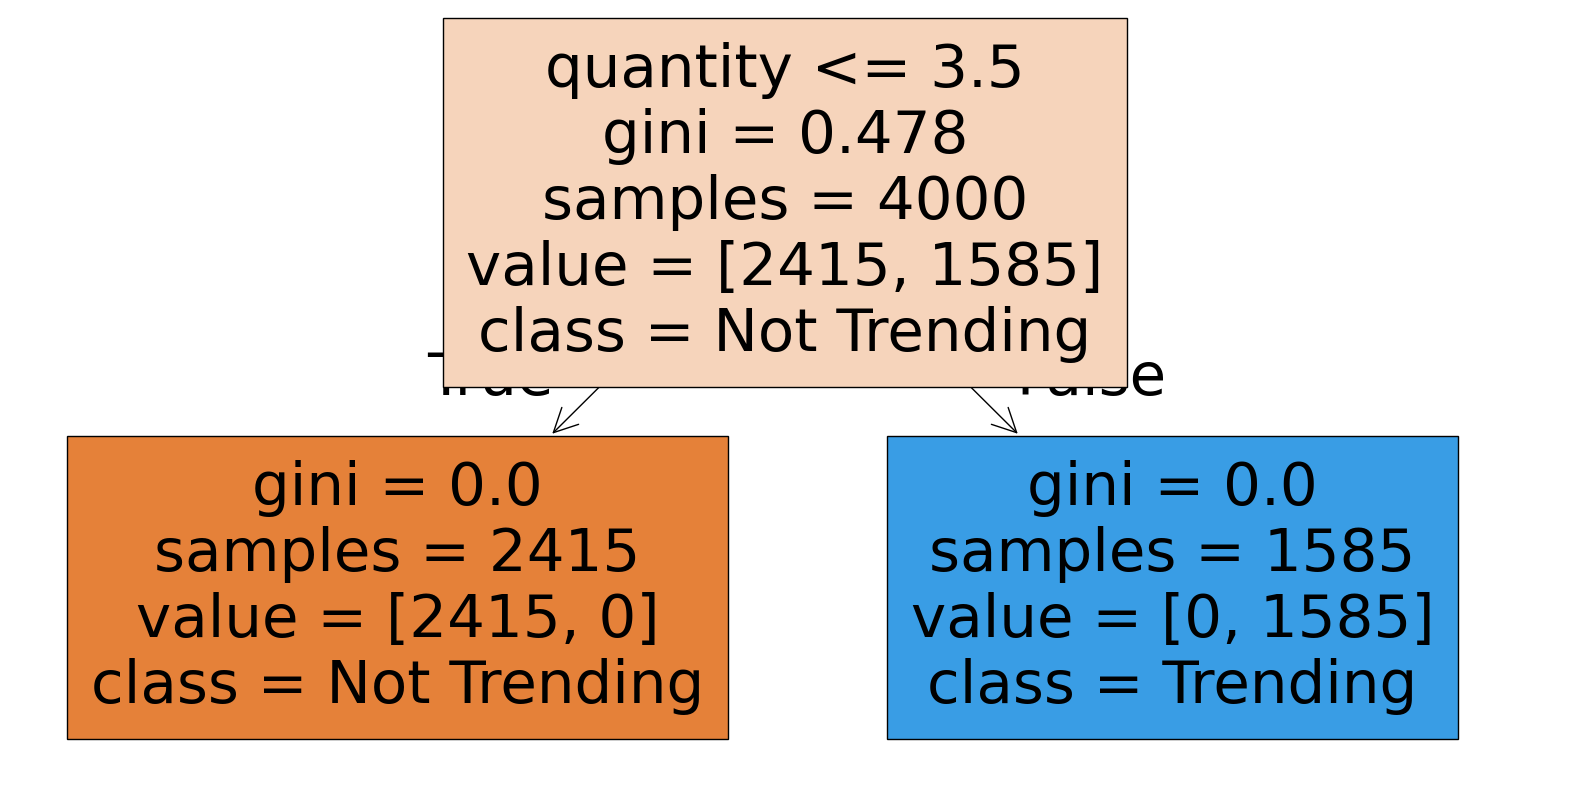

Model Accuracy: 100.00%


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt
import joblib

# --- STEP 1: Feature and Target Selection ---
# X: Input features used for prediction
# y: Target variable (is_trending)
X = df[['category_n', 'sub_cat_n', 'quantity', 'unit_price', 'discount', 'sales', 'profit']]
y = df['is_trending'] 

# --- STEP 2: Data Splitting ---
# 80% for training the model, 20% for testing performance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- STEP 3: Model Training ---
# max_depth=3 prevents overfitting and makes the tree easier to visualize
model_trending = DecisionTreeClassifier(max_depth=3) 
model_trending.fit(X_train, y_train)

# --- STEP 4: Tree Visualization ---
# Plotting the decision logic for the final report
plt.figure(figsize=(20,10))
tree.plot_tree(model_trending, feature_names=X.columns, class_names=['Not Trending', 'Trending'], filled=True)
plt.show()

# --- STEP 5: Model Export ---
# Save the trained model to be used in the Streamlit UI
joblib.dump(model_trending, 'model_trending.pkl')

print(f"Model Accuracy: {model_trending.score(X_test, y_test)*100:.2f}%")

## 3. UI Integration

In [11]:
import joblib

# 1. Simpan Modelnya
joblib.dump(model_bilal, 'model_trending.pkl')

# 2. Simpan LabelEncoder-nya (PENTING!) 
# Agar UI tahu 'Electronics' itu angka berapa
joblib.dump(le, 'label_encoder.pkl')

print("Model dan Encoder berhasil disimpan! Siap dipakai di UI.")

Model dan Encoder berhasil disimpan! Siap dipakai di UI.
